In [2]:
import pandas as pd

# Load the training metadata
train_metadata = pd.read_csv('train_metadata.csv')

# View first few rows
print(train_metadata.head())


                 photo_id                                     path  \
0  B4kTLa3wuM3Mx2tqWd1Adw   train/drink/B4kTLa3wuM3Mx2tqWd1Adw.jpg   
1  ea2a28GJ8SoDdGtB5DhjAA  train/inside/ea2a28GJ8SoDdGtB5DhjAA.jpg   
2  8AOjN0DYw9QHHnuvOlKmqg    train/menu/8AOjN0DYw9QHHnuvOlKmqg.jpg   
3  I0Ya0y4YU52KuOoxmwxFMQ  train/inside/I0Ya0y4YU52KuOoxmwxFMQ.jpg   
4  0o0ZMYBNwPMKj_qSnWKnrQ    train/food/0o0ZMYBNwPMKj_qSnWKnrQ.jpg   

                                       absolute_path   label  \
0  C:\Users\bhoom\Downloads\extracted_yelp_images...   drink   
1  C:\Users\bhoom\Downloads\extracted_yelp_images...  inside   
2  C:\Users\bhoom\Downloads\extracted_yelp_images...    menu   
3  C:\Users\bhoom\Downloads\extracted_yelp_images...  inside   
4  C:\Users\bhoom\Downloads\extracted_yelp_images...    food   

              business_id                          caption  split  file_size  \
0  WwxsLX2Z-SUwiTUs8rsOKg                     Beer Flights  train      20966   
1  PkeGb4MKT2nBi_6w73pa6w  Interio

In [4]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Image size expected by VGG
IMG_SIZE = (224, 224)

# Base directory where 'train/' folder exists
BASE_DIR = 'train'

from tqdm import tqdm

def load_images_from_metadata(df, base_dir=BASE_DIR):
    images = []
    labels = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Loading Images"):
        rel_path = row['path']
        full_path = os.path.join(base_dir, os.path.relpath(rel_path, start='train'))

        try:
            img = load_img(full_path, target_size=IMG_SIZE)
            img = img_to_array(img) / 255.0
            images.append(img)
            labels.append(row['label'])
        except Exception as e:
            print(f"❌ Error loading {rel_path}: {e}")

    return np.array(images), labels


In [11]:
import os

sampled_metadata = train_metadata.sample(n=1000, random_state=42).reset_index(drop=True)
X_img, y_labels = load_images_from_metadata(sampled_metadata)


Loading Images: 100%|██████████| 1000/1000 [00:02<00:00, 467.88it/s]


In [15]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Step 1: Encode labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# Step 2: Convert to one-hot encoding
y_onehot = to_categorical(y_encoded)

# Optional: Check classes
print("Classes:", label_encoder.classes_)


Classes: ['drink' 'food' 'inside' 'menu' 'outside']


In [17]:
print(sampled_metadata.columns)


Index(['photo_id', 'path', 'absolute_path', 'label', 'business_id', 'caption',
       'split', 'file_size', 'modified_time'],
      dtype='object')


In [19]:
from sklearn.preprocessing import StandardScaler

# Extract and scale file_size
X_meta = sampled_metadata[['file_size']]
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)


In [21]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate

# Image input
img_input = Input(shape=(224, 224, 3))
vgg_base = VGG16(include_top=False, weights='imagenet', input_tensor=img_input)
vgg_output = GlobalAveragePooling2D()(vgg_base.output)

# Metadata input
meta_input = Input(shape=(X_meta_scaled.shape[1],))  # e.g., (1,) for file_size
meta_dense = Dense(64, activation='relu')(meta_input)

# Combine both branches
combined = Concatenate()([vgg_output, meta_dense])
x = Dense(128, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(y_onehot.shape[1], activation='softmax')(x)

# Define model
model = Model(inputs=[img_input, meta_input], outputs=output)

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary (optional)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 14,789,317 (56.42 MB)

 Trainable params: 14,789,317 (56.42 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
import time

start_time = time.time()

history = model.fit(
    [X_img, X_meta_scaled],
    y_onehot,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    shuffle=True,
    verbose=1  # Shows progress bar with epoch stats
)

end_time = time.time()

# Print elapsed time
elapsed_time = end_time - start_time
print(f"\n✅ Training completed in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")



Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 644s 26s/step - accuracy: 0.2611 - loss: 2.9743 - val_accuracy: 0.2850 - val_loss: 1.4060
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 675s 27s/step - accuracy: 0.3153 - loss: 1.4406 - val_accuracy: 0.3150 - val_loss: 1.3730
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 707s 28s/step - accuracy: 0.2858 - loss: 1.4571 - val_accuracy: 0.3150 - val_loss: 1.3803
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 669s 27s/step - accuracy: 0.3372 - loss: 1.4213 - val_accuracy: 0.4750 - val_loss: 1.3218
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 641s 26s/step - accuracy: 0.3719 - loss: 1.3286 - val_accuracy: 0.5050 - val_loss: 1.1633
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 633s 25s/step - accuracy: 0.4312 - loss: 1.2536 - val_accuracy: 0.5400 - val_loss: 1.0505
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 643s 26s/step - accuracy: 0.5003 - loss: 1.1107 - val_accuracy: 0.4800 - val_loss: 1.1796
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 624s 25s/step - accuracy: 0.4357 - loss: 1.2360 - val_accuracy: 0.

7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step
✅ Validation Accuracy: 0.5600
✅ Macro F1 Score: 0.3681
✅ Macro AUC Score: 0.8210


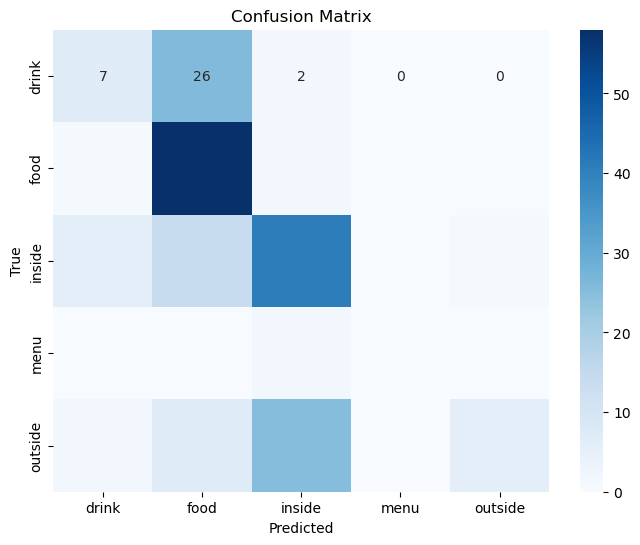

✅ Classification Report:

              precision    recall  f1-score   support

       drink       0.44      0.20      0.27        35
        food       0.55      0.95      0.70        61
      inside       0.57      0.66      0.61        62
        menu       0.00      0.00      0.00         2
     outside       0.86      0.15      0.26        40

    accuracy                           0.56       200
   macro avg       0.48      0.39      0.37       200
weighted avg       0.59      0.56      0.50       200



C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


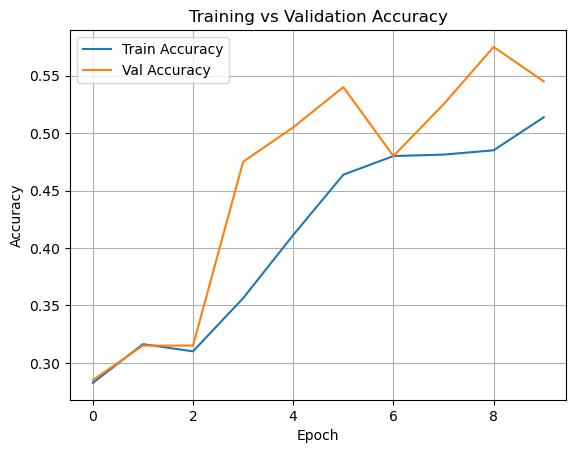

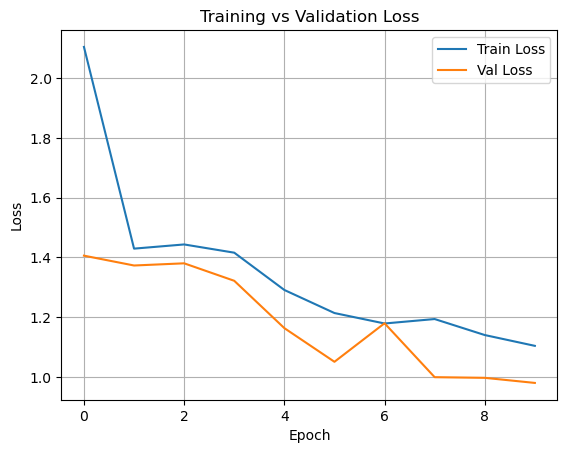

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recover the validation data split manually
from sklearn.model_selection import train_test_split

X_img_train, X_img_val, X_meta_train, X_meta_val, y_train, y_val = train_test_split(
    X_img, X_meta_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot
)

# Predict on validation set
y_pred_proba = model.predict([X_img_val, X_meta_val])
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_val, axis=1)

# Accuracy
val_accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Validation Accuracy: {val_accuracy:.4f}")

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"✅ Macro F1 Score: {f1_macro:.4f}")

# AUC
auc_macro = roc_auc_score(y_val, y_pred_proba, multi_class='ovr')
print(f"✅ Macro AUC Score: {auc_macro:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("✅ Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
